In [1]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

# Resizing data to 256 , and random cropping 224X224 improves performance as Resnet and VGG Models are built with that expectation and trained such .
#As this is transfer learning that size and crop works best . 
#Random Horizontal Flip introduced for better training . Normalized data to Imagenet Mean and Standard Deviation
# Batch size 32 for Resnet models are they are faster and less complex and training time is manageable .
#Batch Size 64 for VGG19 as its more complex model with very high training time . 

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transformer = transforms.Compose([
transforms.Resize(256),
transforms.RandomCrop(224),
transforms.RandomHorizontalFlip(),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

validation_transformer = transforms.Compose([
transforms.Resize(256),
transforms.CenterCrop(224),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

dataset_train = datasets.ImageFolder("dataset10/train", transform=train_transformer, allow_empty=True)
dataset_validation = datasets.ImageFolder("dataset10/val", transform=validation_transformer, allow_empty=True)

dataloader_train = DataLoader(dataset_train, batch_size=32, shuffle=True)
dataloader_validation = DataLoader(dataset_validation, batch_size=32, shuffle=False)


cuda


In [ ]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

for name, param in model.named_parameters():
    print(name)

TRAINING
Train Acc  0.75976
Epoch 1/30, Loss: 0.32410287857055664
Val Acc  0.81
Train Acc  0.8472
Epoch 2/30, Loss: 0.6323837637901306
Val Acc  0.864
Train Acc  0.8732
Epoch 3/30, Loss: 0.5394532680511475
Val Acc  0.89
Train Acc  0.89
Epoch 4/30, Loss: 0.18744005262851715
Val Acc  0.814
Train Acc  0.89664
Epoch 5/30, Loss: 0.5151935815811157
Val Acc  0.91
Train Acc  0.90512
Epoch 6/30, Loss: 0.17802894115447998
Val Acc  0.88
Train Acc  0.91264
Epoch 7/30, Loss: 0.07014172524213791
Val Acc  0.908
Train Acc  0.91936
Epoch 8/30, Loss: 0.38251057267189026
Val Acc  0.912
Train Acc  0.92264
Epoch 9/30, Loss: 0.1668601930141449
Val Acc  0.892
Train Acc  0.92656
Epoch 10/30, Loss: 0.14680704474449158
Val Acc  0.906
Train Acc  0.93248
Epoch 11/30, Loss: 0.18285243213176727
Val Acc  0.912
Train Acc  0.93112
Epoch 12/30, Loss: 0.3464224636554718
Val Acc  0.924
Train Acc  0.9388
Epoch 13/30, Loss: 0.11576910316944122
Val Acc  0.938
Train Acc  0.94096
Epoch 14/30, Loss: 0.27889540791511536
Val Acc 

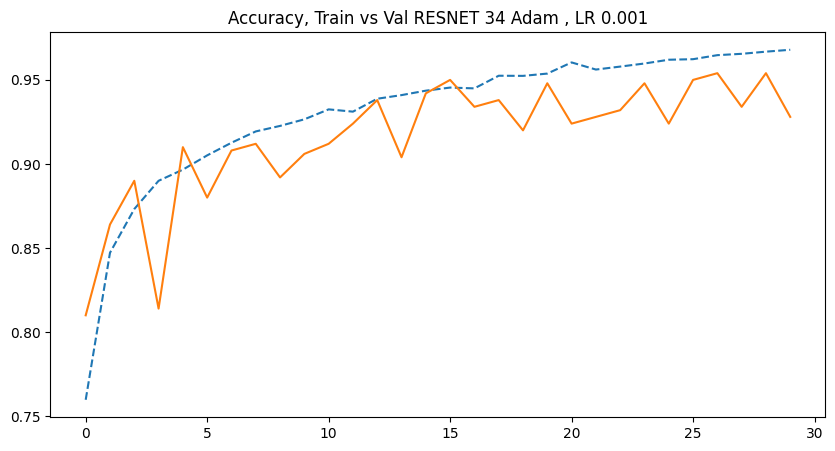

In [2]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING")
epochs=30
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet34_CNN.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val RESNET 34 Adam , LR 0.001")
plt.plot(train_acc_list, label='Train Acc RESNET 34 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc RESNET 34 CNN', linestyle='-')

In [4]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer2.2.conv1.weight
layer2.2.bn1.weight
layer2.2.bn1.bias
layer2.2.conv2.weight
layer2.2.bn2.weight
layer2.2.bn2.bias
layer2.3.conv1.weight
layer2.3.bn1.weight
layer2.3.bn1.bias
layer2.3.conv2.weight
layer2.3.bn2.weight
layer2.3.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight


TRAINING with Step LR Scheduler 
Train Acc  0.21736
Epoch 1/20, Loss: 1.5968483686447144
Val Acc  0.312
Train Acc  0.3756
Epoch 2/20, Loss: 1.5238336324691772
Val Acc  0.414
Train Acc  0.4636
Epoch 3/20, Loss: 0.7754360437393188
Val Acc  0.528
Train Acc  0.57392
Epoch 4/20, Loss: 1.010895848274231
Val Acc  0.638
Train Acc  0.6992
Epoch 5/20, Loss: 0.6073960065841675
Val Acc  0.752
Train Acc  0.73376
Epoch 6/20, Loss: 0.6944848895072937
Val Acc  0.766
Train Acc  0.7536
Epoch 7/20, Loss: 1.06587815284729
Val Acc  0.774
Train Acc  0.77648
Epoch 8/20, Loss: 0.5748047828674316
Val Acc  0.772
Train Acc  0.79872
Epoch 9/20, Loss: 0.7049322724342346
Val Acc  0.822
Train Acc  0.81208
Epoch 10/20, Loss: 1.2162641286849976
Val Acc  0.822
Train Acc  0.80848
Epoch 11/20, Loss: 0.8083251118659973
Val Acc  0.812
Train Acc  0.81968
Epoch 12/20, Loss: 1.3685399293899536
Val Acc  0.83
Train Acc  0.8256
Epoch 13/20, Loss: 0.30891668796539307
Val Acc  0.834
Train Acc  0.8208
Epoch 14/20, Loss: 0.834616184

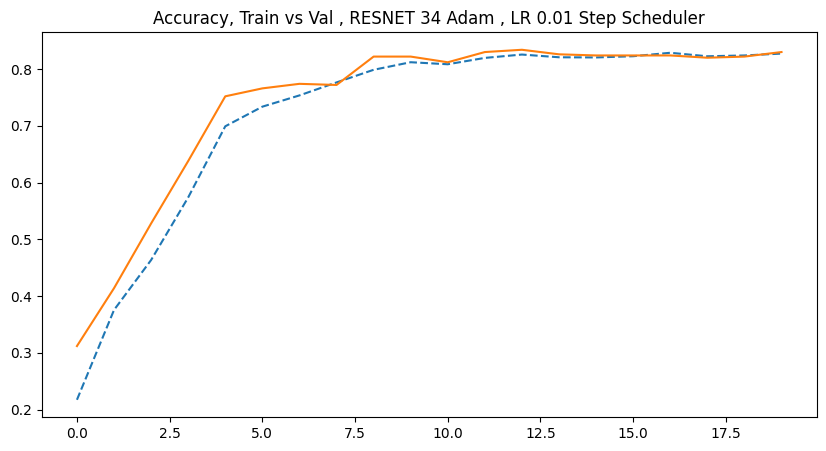

In [5]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING with Step LR Scheduler ")
epochs=20
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet34_CNN_StepScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , RESNET 34 Adam , LR 0.01 Step Scheduler")
plt.plot(train_acc_list, label='Train Acc RESNET 34 CNN Step LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc RESNET 34 CNN  Step LR Scheduler', linestyle='-')


In [6]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer2.2.conv1.weight
layer2.2.bn1.weight
layer2.2.bn1.bias
layer2.2.conv2.weight
layer2.2.bn2.weight
layer2.2.bn2.bias
layer2.3.conv1.weight
layer2.3.bn1.weight
layer2.3.bn1.bias
layer2.3.conv2.weight
layer2.3.bn2.weight
layer2.3.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight


TRAINING with Cosine LR Scheduler 
Train Acc  0.15352
Epoch 1/30, Loss: 2.229862928390503
Val Acc  0.222
Train Acc  0.32376
Epoch 2/30, Loss: 1.6339765787124634
Val Acc  0.402
Train Acc  0.44008
Epoch 3/30, Loss: 1.556623101234436
Val Acc  0.496
Train Acc  0.54648
Epoch 4/30, Loss: 1.5245651006698608
Val Acc  0.654
Train Acc  0.6376
Epoch 5/30, Loss: 1.1411793231964111
Val Acc  0.7
Train Acc  0.68408
Epoch 6/30, Loss: 0.699173092842102
Val Acc  0.704
Train Acc  0.71632
Epoch 7/30, Loss: 0.6825274229049683
Val Acc  0.676
Train Acc  0.75376
Epoch 8/30, Loss: 0.3498586118221283
Val Acc  0.808
Train Acc  0.77656
Epoch 9/30, Loss: 0.594873309135437
Val Acc  0.816
Train Acc  0.79784
Epoch 10/30, Loss: 0.8386561274528503
Val Acc  0.794
Train Acc  0.81192
Epoch 11/30, Loss: 1.0906431674957275
Val Acc  0.8
Train Acc  0.8288
Epoch 12/30, Loss: 0.6263937950134277
Val Acc  0.846
Train Acc  0.84112
Epoch 13/30, Loss: 0.6541205048561096
Val Acc  0.846
Train Acc  0.8592
Epoch 14/30, Loss: 0.421180427

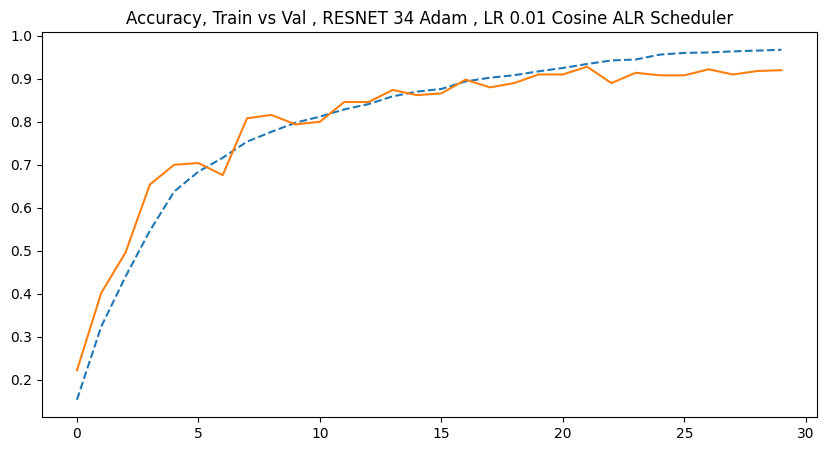

In [7]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING with Cosine LR Scheduler ")
epochs=30
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  scheduler.step()    
  train_acc = correct / total
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet34_CNN_ADAM_CosineALRScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , RESNET 34 Adam , LR 0.01 Cosine ALR Scheduler")
plt.plot(train_acc_list, label='Train Acc RESNET 34 CNN Cosine LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc RESNET 34 CNN  Cosine LR Scheduler', linestyle='-')


In [2]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer2.2.conv1.weight
layer2.2.bn1.weight
layer2.2.bn1.bias
layer2.2.conv2.weight
layer2.2.bn2.weight
layer2.2.bn2.bias
layer2.3.conv1.weight
layer2.3.bn1.weight
layer2.3.bn1.bias
layer2.3.conv2.weight
layer2.3.bn2.weight
layer2.3.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight


TRAINING with Cosine LR Scheduler SGD 
Train Acc  0.95064
Epoch 1/20, Loss: 0.16000445187091827
Val Acc  0.98
Train Acc  0.97104
Epoch 2/20, Loss: 0.015017825178802013
Val Acc  0.974
Train Acc  0.97488
Epoch 3/20, Loss: 0.26211610436439514
Val Acc  0.988
Train Acc  0.98096
Epoch 4/20, Loss: 0.03534775599837303
Val Acc  0.984
Train Acc  0.98504
Epoch 5/20, Loss: 0.010386014357209206
Val Acc  0.98
Train Acc  0.9844
Epoch 6/20, Loss: 0.07206986844539642
Val Acc  0.978
Train Acc  0.98672
Epoch 7/20, Loss: 0.2188679277896881
Val Acc  0.978
Train Acc  0.98832
Epoch 8/20, Loss: 0.009958858601748943
Val Acc  0.982
Train Acc  0.98968
Epoch 9/20, Loss: 0.0016185190761461854
Val Acc  0.98
Train Acc  0.99144
Epoch 10/20, Loss: 0.2392771989107132
Val Acc  0.986
Train Acc  0.99112
Epoch 11/20, Loss: 0.006488134618848562
Val Acc  0.984
Train Acc  0.99216
Epoch 12/20, Loss: 0.015767855569720268
Val Acc  0.982
Train Acc  0.99352
Epoch 13/20, Loss: 0.018000297248363495
Val Acc  0.986
Train Acc  0.99296


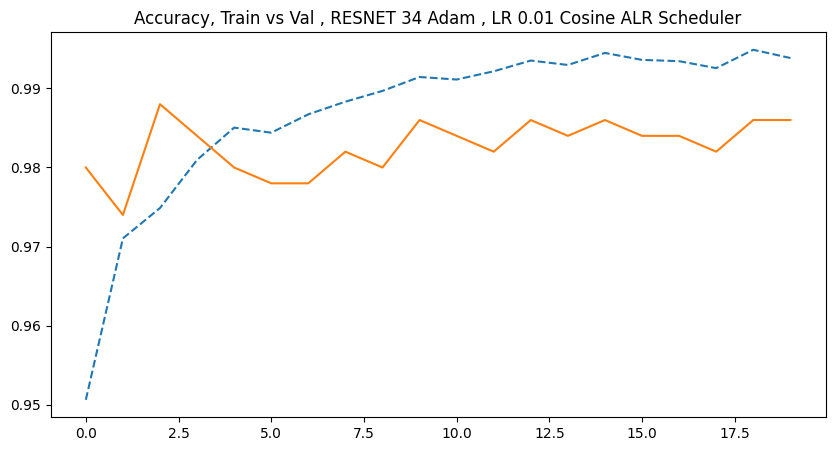

In [5]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING with Cosine LR Scheduler SGD ")
epochs=20
optimizer = optim.SGD(model.parameters(), lr=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet34_CNN_SGD_CosineALRScheduler.pth')

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val , RESNET 34 Adam , LR 0.01 Cosine ALR Scheduler")
plt.plot(train_acc_list, label='Train Acc RESNET 34 CNN Cosine LR Scheduler', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc RESNET 34 CNN  Cosine LR Scheduler', linestyle='-')


In [6]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer2.2.conv1.weight
layer2.2.bn1.weight
layer2.2.bn1.bias
layer2.2.conv2.weight
layer2.2.bn2.weight
layer2.2.bn2.bias
layer2.3.conv1.weight
layer2.3.bn1.weight
layer2.3.bn1.bias
layer2.3.conv2.weight
layer2.3.bn2.weight
layer2.3.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight


TRAINING Adam Cosine ALR 0.01 Weight Decay
Train Acc  0.19992
Epoch 1/20, Loss: 2.0703248977661133
Val Acc  0.252
Train Acc  0.34552
Epoch 2/20, Loss: 1.804396629333496
Val Acc  0.29
Train Acc  0.42072
Epoch 3/20, Loss: 1.5021355152130127
Val Acc  0.516
Train Acc  0.49312
Epoch 4/20, Loss: 1.438533902168274
Val Acc  0.474
Train Acc  0.54832
Epoch 5/20, Loss: 0.7899986505508423
Val Acc  0.638
Train Acc  0.59824
Epoch 6/20, Loss: 1.3756678104400635
Val Acc  0.584
Train Acc  0.63344
Epoch 7/20, Loss: 1.3529040813446045
Val Acc  0.698
Train Acc  0.6572
Epoch 8/20, Loss: 1.1350963115692139
Val Acc  0.552
Train Acc  0.68848
Epoch 9/20, Loss: 0.5525130033493042
Val Acc  0.668
Train Acc  0.70552
Epoch 10/20, Loss: 0.9822672605514526
Val Acc  0.72
Train Acc  0.73072
Epoch 11/20, Loss: 0.9357062578201294
Val Acc  0.746
Train Acc  0.74352
Epoch 12/20, Loss: 0.8671162724494934
Val Acc  0.728
Train Acc  0.76344
Epoch 13/20, Loss: 0.7001805305480957
Val Acc  0.796
Train Acc  0.782
Epoch 14/20, Loss:

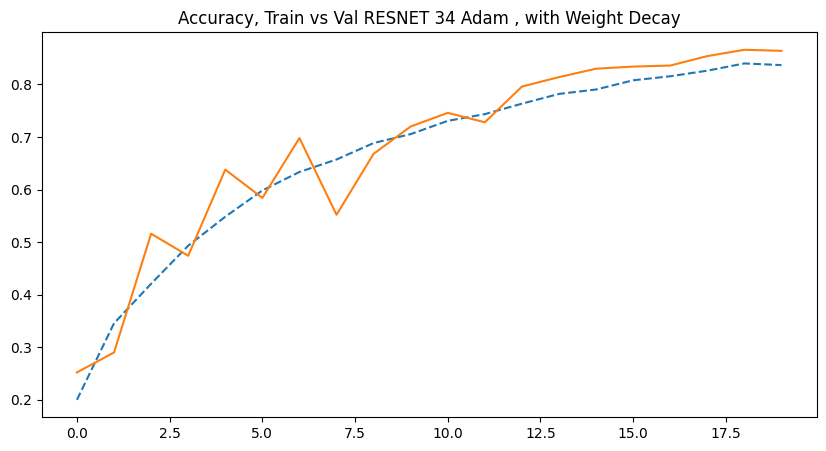

In [8]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING Adam Cosine ALR 0.01 Weight Decay")
epochs=20
optimizer = optim.Adam(model.parameters(), lr=0.01,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet34_CNN_Adam_CosineALR_WeightDecay.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val RESNET 34 Adam , with Weight Decay")
plt.plot(train_acc_list, label='Train Acc RESNET 34 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc RESNET 34 CNN', linestyle='-')

In [9]:
model = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

for name, param in model.named_parameters():
    print(name)

conv1.weight
bn1.weight
bn1.bias
layer1.0.conv1.weight
layer1.0.bn1.weight
layer1.0.bn1.bias
layer1.0.conv2.weight
layer1.0.bn2.weight
layer1.0.bn2.bias
layer1.1.conv1.weight
layer1.1.bn1.weight
layer1.1.bn1.bias
layer1.1.conv2.weight
layer1.1.bn2.weight
layer1.1.bn2.bias
layer1.2.conv1.weight
layer1.2.bn1.weight
layer1.2.bn1.bias
layer1.2.conv2.weight
layer1.2.bn2.weight
layer1.2.bn2.bias
layer2.0.conv1.weight
layer2.0.bn1.weight
layer2.0.bn1.bias
layer2.0.conv2.weight
layer2.0.bn2.weight
layer2.0.bn2.bias
layer2.0.downsample.0.weight
layer2.0.downsample.1.weight
layer2.0.downsample.1.bias
layer2.1.conv1.weight
layer2.1.bn1.weight
layer2.1.bn1.bias
layer2.1.conv2.weight
layer2.1.bn2.weight
layer2.1.bn2.bias
layer2.2.conv1.weight
layer2.2.bn1.weight
layer2.2.bn1.bias
layer2.2.conv2.weight
layer2.2.bn2.weight
layer2.2.bn2.bias
layer2.3.conv1.weight
layer2.3.bn1.weight
layer2.3.bn1.bias
layer2.3.conv2.weight
layer2.3.bn2.weight
layer2.3.bn2.bias
layer3.0.conv1.weight
layer3.0.bn1.weight


TRAINING SGD Cosine ALR 0.01 Weight Decay 
Train Acc  0.91688
Epoch 1/20, Loss: 0.06277976185083389
Val Acc  0.98
Train Acc  0.96144
Epoch 2/20, Loss: 0.05756964161992073
Val Acc  0.982
Train Acc  0.9696
Epoch 3/20, Loss: 0.07288631796836853
Val Acc  0.982
Train Acc  0.97672
Epoch 4/20, Loss: 0.25618964433670044
Val Acc  0.978
Train Acc  0.9828
Epoch 5/20, Loss: 0.07372070103883743
Val Acc  0.984
Train Acc  0.98456
Epoch 6/20, Loss: 0.006860530935227871
Val Acc  0.98
Train Acc  0.98584
Epoch 7/20, Loss: 0.22929659485816956
Val Acc  0.982
Train Acc  0.98888
Epoch 8/20, Loss: 0.0023192097432911396
Val Acc  0.986
Train Acc  0.98968
Epoch 9/20, Loss: 0.036003079265356064
Val Acc  0.986
Train Acc  0.99112
Epoch 10/20, Loss: 0.004292493686079979
Val Acc  0.98
Train Acc  0.99072
Epoch 11/20, Loss: 0.046509090811014175
Val Acc  0.982
Train Acc  0.99208
Epoch 12/20, Loss: 0.01591619849205017
Val Acc  0.984
Train Acc  0.9928
Epoch 13/20, Loss: 0.006842168979346752
Val Acc  0.986
Train Acc  0.993

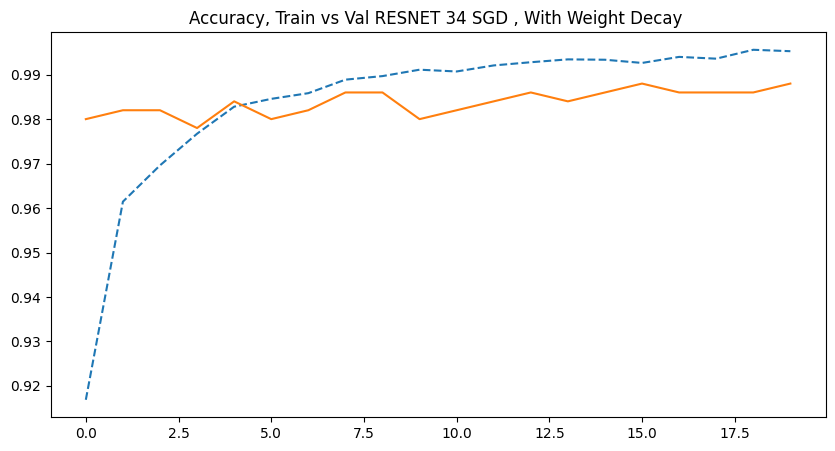

In [11]:
num_classes = 10
model.fc = nn.Linear(model.fc.in_features, num_classes)
train_acc_list = []
val_acc_list = []

print("TRAINING SGD Cosine ALR 0.01 Weight Decay ")
epochs=20
optimizer = optim.SGD(model.parameters(), lr=0.01,  weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

loss_func = nn.CrossEntropyLoss()
model.cuda(device)
for epoch in range(epochs):
  correct, total = 0, 0  
  model.train()
  for images, labels in dataloader_train:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
  train_acc = correct / total
  scheduler.step()  
  print("Train Acc ", train_acc)  
  train_acc_list.append(train_acc)
  print(f"Epoch {epoch + 1}/{epochs}, Loss: {loss.item()}")
  
  model.eval()
  correct_val = 0
  total_val = 0
  with torch.no_grad():
        for images, labels in dataloader_validation:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
        val_acc = correct_val / total_val
        print("Val Acc ", val_acc)  
        val_acc_list.append(val_acc)  

torch.save(model, 'resnet34_CNN_SGD_CosineALR_WeightDecay.pth')
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.title("Accuracy, Train vs Val RESNET 34 SGD , With Weight Decay ")
plt.plot(train_acc_list, label='Train Acc RESNET 34 CNN', linestyle='--')
plt.plot(val_acc_list, label='Validation Acc RESNET 34 CNN', linestyle='-')

In [1]:
from torch import optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(device)

# Resizing data to 256 , and random cropping 224X224 improves performance as Resnet and VGG Models are built with that expectation and trained such .
#As this is transfer learning that size and crop works best . 
#Random Horizontal Flip introduced for better training . Normalized data to Imagenet Mean and Standard Deviation
# Batch size 32 for Resnet models are they are faster and less complex and training time is manageable .


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

validation_transformer = transforms.Compose([
transforms.Resize(256),
transforms.CenterCrop(224),
transforms.ToTensor(),
transforms.Normalize(imagenet_mean, imagenet_std)
])

dataset_test = datasets.ImageFolder("dataset10/test", transform=validation_transformer, allow_empty=True)

dataloader_test = DataLoader(dataset_test, batch_size=32, shuffle=False)
print("Setup Complete")

cuda
Setup Complete


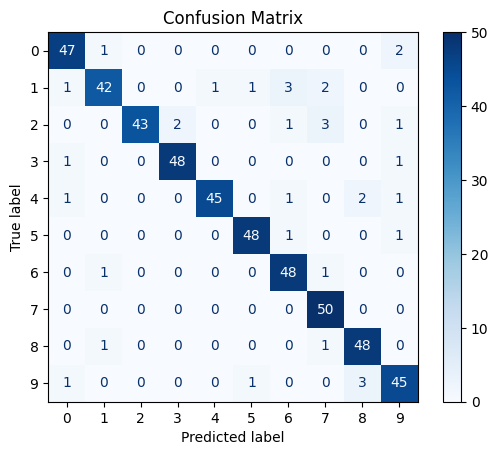

464
500
Test Accuracy: 92.80%
Precision: 0.93
Recall:    0.93
F1 Score:  0.93


In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet34_CNN.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

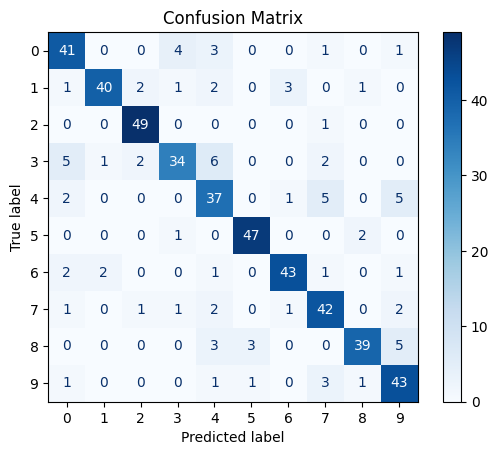

415
500
Test Accuracy: 83.00%
Precision: 0.84
Recall:    0.83
F1 Score:  0.83


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet34_CNN_StepScheduler.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

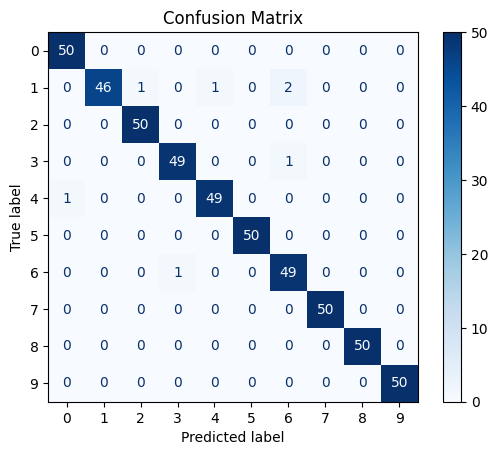

493
500
Test Accuracy: 98.60%
Precision: 0.99
Recall:    0.99
F1 Score:  0.99


In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet34_CNN_SGD_CosineALRScheduler.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

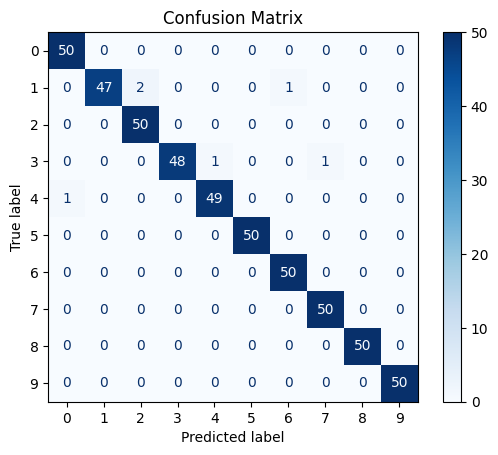

494
500
Test Accuracy: 98.80%
Precision: 0.99
Recall:    0.99
F1 Score:  0.99


In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet34_CNN_SGD_CosineALR_WeightDecay.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

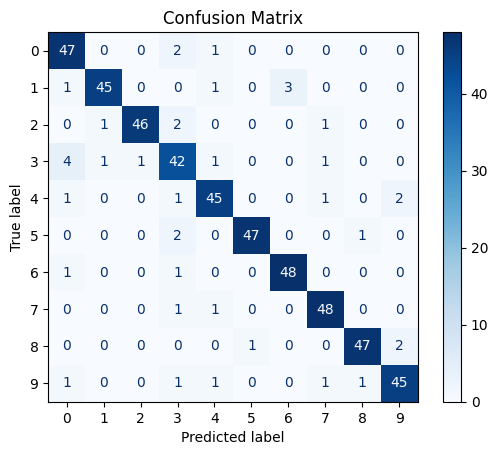

460
500
Test Accuracy: 92.00%
Precision: 0.92
Recall:    0.92
F1 Score:  0.92


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet34_CNN_ADAM_CosineALRScheduler.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 

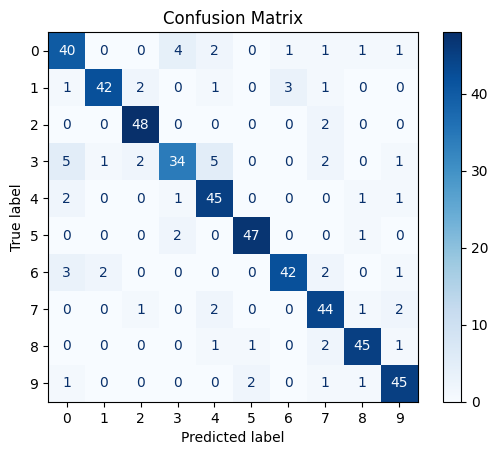

432
500
Test Accuracy: 86.40%
Precision: 0.87
Recall:    0.86
F1 Score:  0.86


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score
from torchmetrics.classification import AUROC

model = torch.load('resnet34_CNN_Adam_CosineALR_WeightDecay.pth', weights_only=False)

model.eval()
correct = 0
total = 0
all_labels =[]
all_predictions=[]
with torch.no_grad():
  for images, labels in dataloader_test:
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()
    all_labels.extend(labels.to("cpu").numpy())
    all_predictions.extend(predicted.to("cpu").numpy())
  cm = confusion_matrix(all_labels, all_predictions)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(cmap='Blues')
  plt.title('Confusion Matrix')
  plt.show()
  print(correct)
  print(total)
  print(f"Test Accuracy: {100 * correct / total:.2f}%")
  precision = precision_score(all_labels, all_predictions, average='weighted')
  recall = recall_score(all_labels, all_predictions, average='weighted')
  f1 = f1_score(all_labels, all_predictions, average='weighted')
  print(f"Precision: {precision:.2f}")
  print(f"Recall:    {recall:.2f}")
  print(f"F1 Score:  {f1:.2f}")
 